In [1]:
!pip install -u transformers accelerate
!pip install bitsandbytes datasets
!pip install huggingface_hub
!pip install matplotlib
!pip install pandas


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.7 MB/s eta 0:00:00


In [2]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Importing required Libraries

In [3]:
import torch, time, pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

### Preparing the dataset

In [4]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

texts = [t for t in dataset["text"] if len(t.strip()) > 20][:5]
print("Sample count:", len(texts))

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Sample count: 5


In [5]:
def benchmark(model, tokenizer, texts, name):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # cleaning up before measuring
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    times = []
    for text in texts:
        inputs = tokenizer(
            text, return_tensors="pt",
            truncation=True, max_length=128
        ).to(device)

        t0 = time.time()
        with torch.no_grad():
            _ = model.generate(**inputs, max_new_tokens=50)
        t1 = time.time()

        times.append(t1 - t0)

    avg_time = sum(times) / len(times)

    peak_vram = 0
    if torch.cuda.is_available():
        peak_vram = torch.cuda.max_memory_allocated() / (1024**3)

    return {
        "Model": name,
        "Avg Time (s)": round(avg_time, 4),
        "Peak VRAM (GB)": round(peak_vram, 3)
    }

### GPT Loader(INT8/INT$)

In [6]:
def load_gpt2(quant=None):
    if quant == "int8":
        config = BitsAndBytesConfig(load_in_8bit=True)
    elif quant == "int4":
        config = BitsAndBytesConfig(load_in_4bit=True)
    else:
        config = None

    model = AutoModelForCausalLM.from_pretrained(
        "gpt2",
        quantization_config=config,
        device_map="auto"
    )

    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer

### LLaMA-2 (7B)

In [8]:
llama_id = "meta-llama/Llama-2-7b-hf"

bnb_nf4 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

model_llama = AutoModelForCausalLM.from_pretrained(
    llama_id,
    quantization_config=bnb_nf4,
    device_map="auto"
)

tokenizer_llama = AutoTokenizer.from_pretrained(llama_id)
tokenizer_llama.pad_token = tokenizer_llama.eos_token

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

### Running Experiments

In [9]:
results = []

# GPT-2 FP16
m, t = load_gpt2(None)
results.append(benchmark(m, t, texts, "GPT2 FP16"))

# GPT-2 INT8
m, t = load_gpt2("int8")
results.append(benchmark(m, t, texts, "GPT2 INT8"))

# GPT-2 INT4
m, t = load_gpt2("int4")
results.append(benchmark(m, t, texts, "GPT2 INT4"))

# LLaMA-2 7B (NF4 4-bit)
results.append(benchmark(model_llama, tokenizer_llama, texts, "LLaMA2-7B (NF4)"))

df = pd.DataFrame(results)
print(df)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


             Model  Avg Time (s)  Peak VRAM (GB)
0        GPT2 FP16        2.2989           4.394
1        GPT2 INT8        4.6873           4.167
2        GPT2 INT4        0.7321           4.122
3  LLaMA2-7B (NF4)        2.9226           4.255


### Plotings

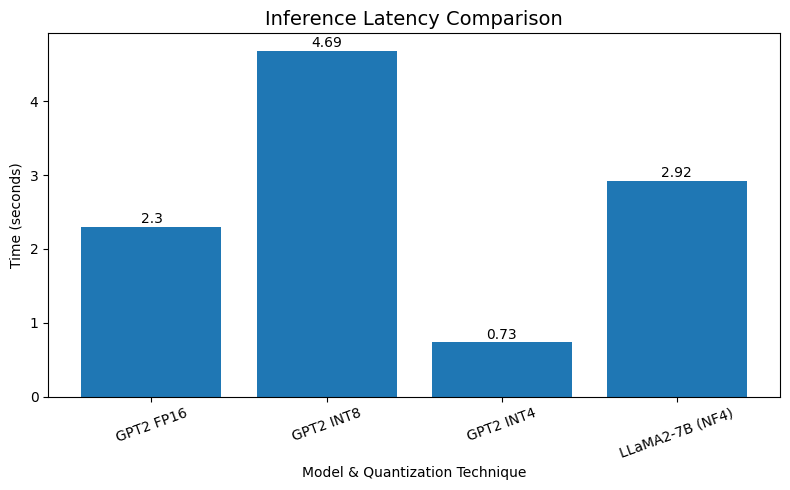

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["Model"], df["Avg Time (s)"])
plt.title("Inference Latency Comparison", fontsize=14)
plt.xlabel("Model & Quantization Technique")
plt.ylabel("Time (seconds)")

for i, v in enumerate(df["Avg Time (s)"]):
    plt.text(i, v + 0.05, str(round(v,2)), ha='center')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Plotting VRAM

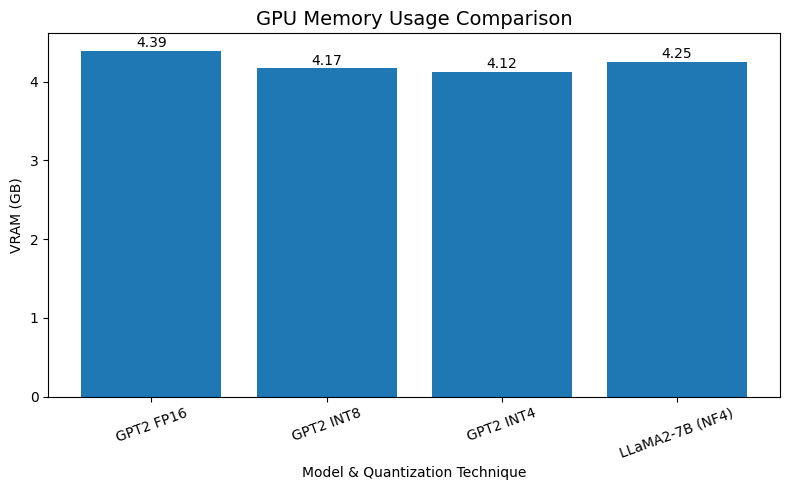

In [15]:
plt.figure(figsize=(8,5))

plt.bar(df["Model"], df["Peak VRAM (GB)"])
plt.title("GPU Memory Usage Comparison", fontsize=14)
plt.xlabel("Model & Quantization Technique")
plt.ylabel("VRAM (GB)")

for i, v in enumerate(df["Peak VRAM (GB)"]):
    plt.text(i, v + 0.05, str(round(v,2)), ha='center')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Saving the results

In [13]:
df.to_csv("quantization_results.csv", index=False)